# Prediksi Kelulusan Mahasiswa Menggunakan Machine Learning

## Business Understanding

### Latar Belakang

Kelulusan mahasiswa tepat waktu merupakan salah satu indikator penting dalam mengevaluasi kualitas pendidikan di perguruan tinggi. Namun, banyak institusi masih mengalami kesulitan dalam mengidentifikasi mahasiswa yang berpotensi terlambat lulus sejak dini. Akibatnya, tindakan pencegahan atau pendampingan akademik sering terlambat diberikan.

Machine Learning dapat dimanfaatkan untuk mempelajari pola dari data akademik mahasiswa sehingga mampu memprediksi kemungkinan mahasiswa mengalami dropout atau tidak. Hasil prediksi tersebut diharapkan dapat membantu pihak kampus dalam mengambil keputusan secara lebih cepat dan tepat.

### Permasalahan

- Sulit mengidentifikasi mahasiswa yang berpotensi mengalami dropout sejak dini.
- Monitoring akademik masih dilakukan secara manual.
- Belum terdapat sistem prediksi yang mampu membantu pengambilan keputusan berbasis data.

### Tujuan

- Membangun model Machine Learning untuk memprediksi status kelulusan mahasiswa.
- Membandingkan performa Decision Tree, XGBoost dan Logistic Regression.

# Data Understanding


In [ ]:
import pandas as pd

df = pd.read_csv('/content/student_dropout_dataset_v3.csv')

df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [ ]:
print("=== INFORMASI DATASET ===")
df.info()

print("\n=== PROPORSISI KOLOM TARGET (DROPOUT) ===")
print(df['Dropout'].value_counts())

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 

##Dataset Overview

In [ ]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


## Missing Value Analysis

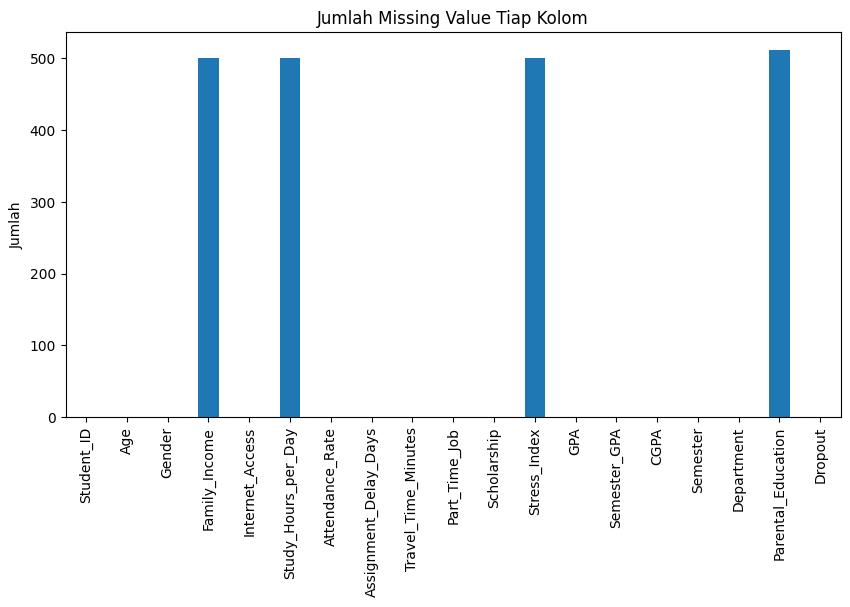

In [ ]:
import matplotlib.pyplot as plt

missing = df.isnull().sum()

plt.figure(figsize=(10,5))
missing.plot(kind='bar')
plt.title("Jumlah Missing Value Tiap Kolom")
plt.ylabel("Jumlah")
plt.show()

## Duplicate Data Analysis

In [ ]:
duplicates = df.duplicated().sum()

print(f"Jumlah data duplikat: {duplicates}")

Jumlah data duplikat: 0


## Data Inconsistency Analysis
Berdasarkan hasil pemeriksaan dataset, tidak ditemukan inkonsistensi pada penamaan kategori maupun tipe data. Setiap atribut telah memiliki tipe data yang sesuai sehingga dapat digunakan pada tahap preprocessing setelah dilakukan penanganan missing values.

## Outlier Analysis

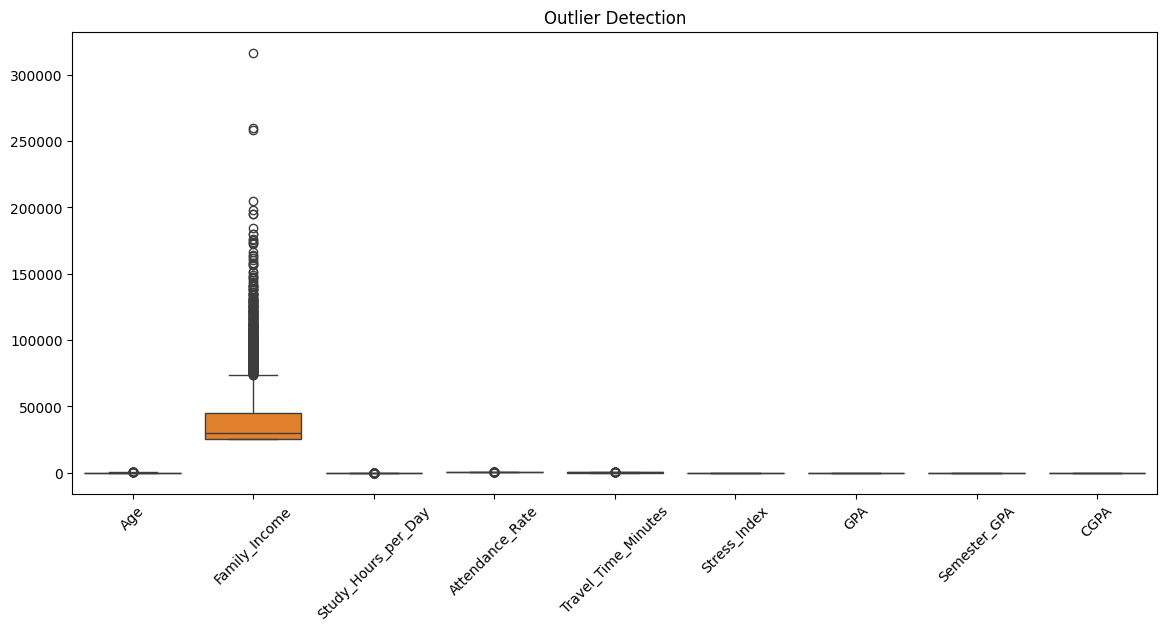

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = [
    'Age',
    'Family_Income',
    'Study_Hours_per_Day',
    'Attendance_Rate',
    'Travel_Time_Minutes',
    'Stress_Index',
    'GPA',
    'Semester_GPA',
    'CGPA'
]

plt.figure(figsize=(14,6))
sns.boxplot(data=df[numerical_columns])

plt.xticks(rotation=45)
plt.title("Outlier Detection")
plt.show()

## Target Distribution


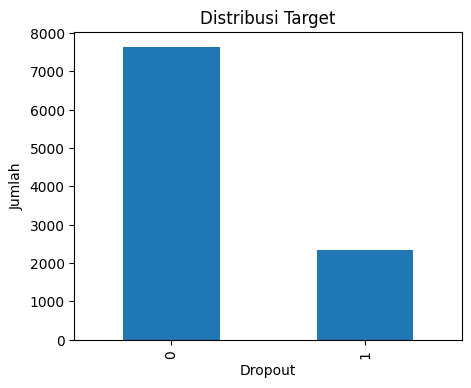

In [ ]:
plt.figure(figsize=(5,4))
df['Dropout'].value_counts().plot(kind='bar')
plt.title("Distribusi Target")
plt.xlabel("Dropout")
plt.ylabel("Jumlah")
plt.show()

## Numerical Feature Distribution


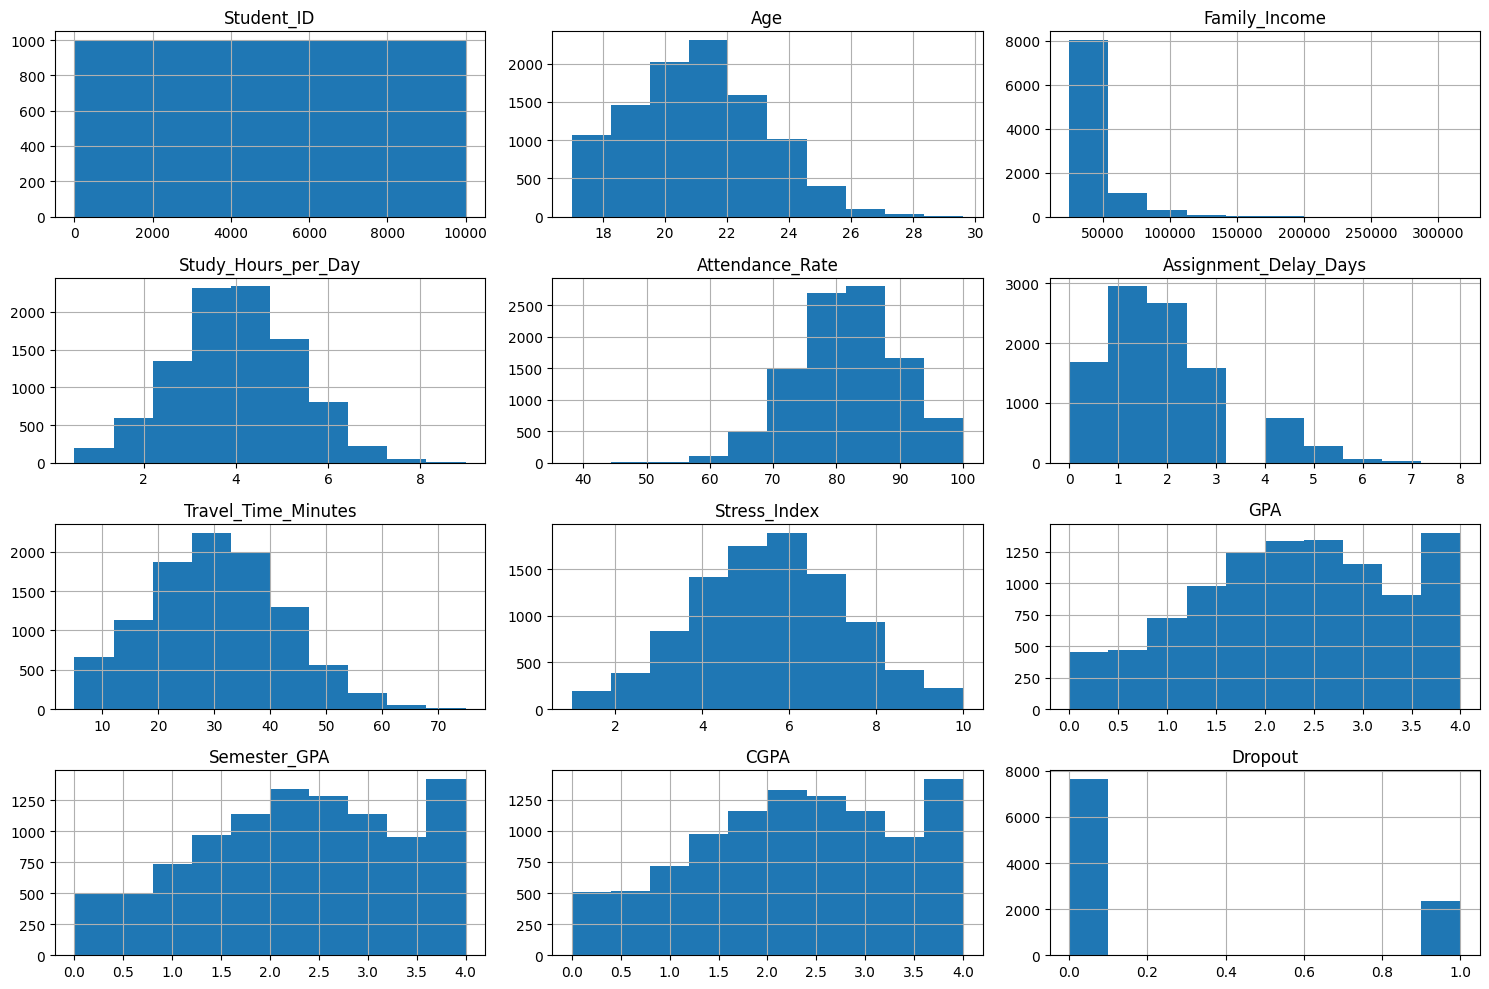

In [ ]:
numeric = df.select_dtypes(include=['int64','float64'])

numeric.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

## Correlation Analysis

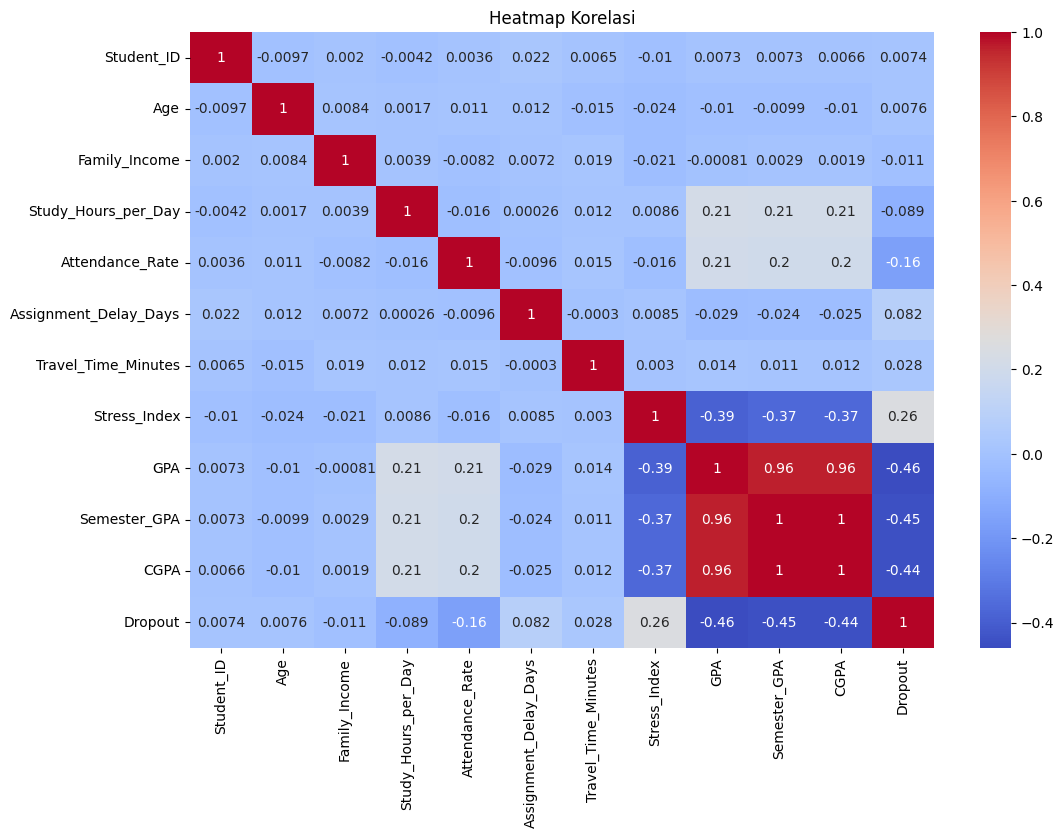

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Heatmap Korelasi")
plt.savefig("correlation_heatmap.png",dpi=300,bbox_inches="tight")
plt.show()

# Data Preparation



### Missing Value Handling

In [ ]:
kolom_numerik = ['Family_Income', 'Study_Hours_per_Day', 'Stress_Index']
for col in kolom_numerik:
    df[col] = df[col].fillna(df[col].median())

df['Parental_Education'] = df['Parental_Education'].fillna(df['Parental_Education'].mode()[0])

print("=== JUMLAH DATA KOSONG PER KOLOM ===")
print(df.isnull().sum())

=== JUMLAH DATA KOSONG PER KOLOM ===
Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64


### Categorical Encoding

In [ ]:
kolom_biner = ['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship']

for col in kolom_biner:
    df[col] = df[col].astype('category').cat.codes

df[['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship']].head()

,Gender,Internet_Access,Part_Time_Job,Scholarship
0,1,1,1,0
1,1,1,0,0
2,1,1,1,0
3,1,1,0,0
4,0,1,0,0


In [ ]:
kolom_sisa = ['Semester', 'Department', 'Parental_Education']

for col in kolom_sisa:
    df[col] = df[col].astype('category').cat.codes

df.dtypes

,0
Student_ID,int64
Age,float64
Gender,int8
Family_Income,float64
Internet_Access,int8
Study_Hours_per_Day,float64
Attendance_Rate,float64
Assignment_Delay_Days,int64
Travel_Time_Minutes,float64
Part_Time_Job,int8


###Feature Selection

In [ ]:
X = df.drop(columns=['Student_ID', 'Dropout'])

y = df['Dropout']

print("Ukuran Fitur X (Baris, Kolom):", X.shape)
print("Ukuran Target y (Baris):", y.shape)

Ukuran Fitur X (Baris, Kolom): (10000, 17)
Ukuran Target y (Baris): (10000,)


### Train and Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("=== HASIL PEMBAGIAN DATA ===")
print(f"Training Set   : {X_train.shape}")
print(f"Validation Set : {X_val.shape}")
print(f"Testing Set    : {X_test.shape}")

=== HASIL PEMBAGIAN DATA ===
Training Set   : (8000, 17)
Validation Set : (1000, 17)
Testing Set    : (1000, 17)


### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("=== FEATURE SCALING SELESAI ===")
print("X_train_scaled :", X_train_scaled.shape)
print("X_val_scaled   :", X_val_scaled.shape)
print("X_test_scaled  :", X_test_scaled.shape)

=== FEATURE SCALING SELESAI ===
X_train_scaled : (8000, 17)
X_val_scaled   : (1000, 17)
X_test_scaled  : (1000, 17)


# Modeling


### Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_dt = DecisionTreeClassifier(
    random_state=42
)

model_xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

model_lr.fit(X_train_scaled, y_train)
model_dt.fit(X_train, y_train)
model_xgb.fit(X_train, y_train)

print("=== MODEL TRAINING SELESAI ===")
print("Logistic Regression")
print("Decision Tree")
print("XGBoost")

=== MODEL TRAINING SELESAI ===
Logistic Regression
Decision Tree
XGBoost


###Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_lr = {
    "C":[0.01,0.1,1,10]
}

grid_lr = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    param_lr,
    cv=5,
    scoring="accuracy"
)

grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_

param_dt = {
    "criterion":["gini","entropy"],
    "max_depth":[3,5,7,10],
    "min_samples_split":[2,5,10]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt,
    cv=5,
    scoring="accuracy"
)

grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

param_xgb = {
    "n_estimators":[100,200],
    "max_depth":[3,5],
    "learning_rate":[0.01,0.1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_xgb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

print("=== HYPERPARAMETER TUNING SELESAI ===")

=== HYPERPARAMETER TUNING SELESAI ===


###Validation

In [ ]:
from sklearn.metrics import accuracy_score

pred_lr_val = best_lr.predict(X_val_scaled)
pred_dt_val = best_dt.predict(X_val)
pred_xgb_val = best_xgb.predict(X_val)

print("=== VALIDATION RESULT ===")
print(f"Logistic Regression : {accuracy_score(y_val, pred_lr_val):.4f}")
print(f"Decision Tree       : {accuracy_score(y_val, pred_dt_val):.4f}")
print(f"XGBoost             : {accuracy_score(y_val, pred_xgb_val):.4f}")

=== VALIDATION RESULT ===
Logistic Regression : 0.8250
Decision Tree       : 0.8180
XGBoost             : 0.8130


#Evaluation

###Model Performance Comparison

####Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

pred_lr = best_lr.predict(X_test_scaled)
pred_dt = best_dt.predict(X_test)
pred_xgb = best_xgb.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)
acc_dt = accuracy_score(y_test, pred_dt)
acc_xgb = accuracy_score(y_test, pred_xgb)

print("=== MODEL ACCURACY ===")
print(f"Logistic Regression : {acc_lr:.4f}")
print(f"Decision Tree       : {acc_dt:.4f}")
print(f"XGBoost             : {acc_xgb:.4f}")

=== MODEL ACCURACY ===
Logistic Regression : 0.7980
Decision Tree       : 0.7860
XGBoost             : 0.7960


####Classification Report

In [ ]:
from sklearn.metrics import classification_report

print("=== LOGISTIC REGRESSION ===")
print(classification_report(
    y_test,
    pred_lr,
    target_names=["Graduate","Dropout"]
))

print("\n=============================\n")

print("=== DECISION TREE ===")
print(classification_report(
    y_test,
    pred_dt,
    target_names=["Graduate","Dropout"]
))

print("\n=============================\n")

print("=== XGBOOST ===")
print(classification_report(
    y_test,
    pred_xgb,
    target_names=["Graduate","Dropout"]
))

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

    Graduate       0.82      0.93      0.88       765
     Dropout       0.62      0.35      0.45       235

    accuracy                           0.80      1000
   macro avg       0.72      0.64      0.66      1000
weighted avg       0.78      0.80      0.78      1000



=== DECISION TREE ===
              precision    recall  f1-score   support

    Graduate       0.83      0.91      0.87       765
     Dropout       0.57      0.37      0.45       235

    accuracy                           0.79      1000
   macro avg       0.70      0.64      0.66      1000
weighted avg       0.76      0.79      0.77      1000



=== XGBOOST ===
              precision    recall  f1-score   support

    Graduate       0.82      0.95      0.88       765
     Dropout       0.63      0.31      0.42       235

    accuracy                           0.80      1000
   macro avg       0.73      0.63      0.65      1000
weig

###Confusion Matrix

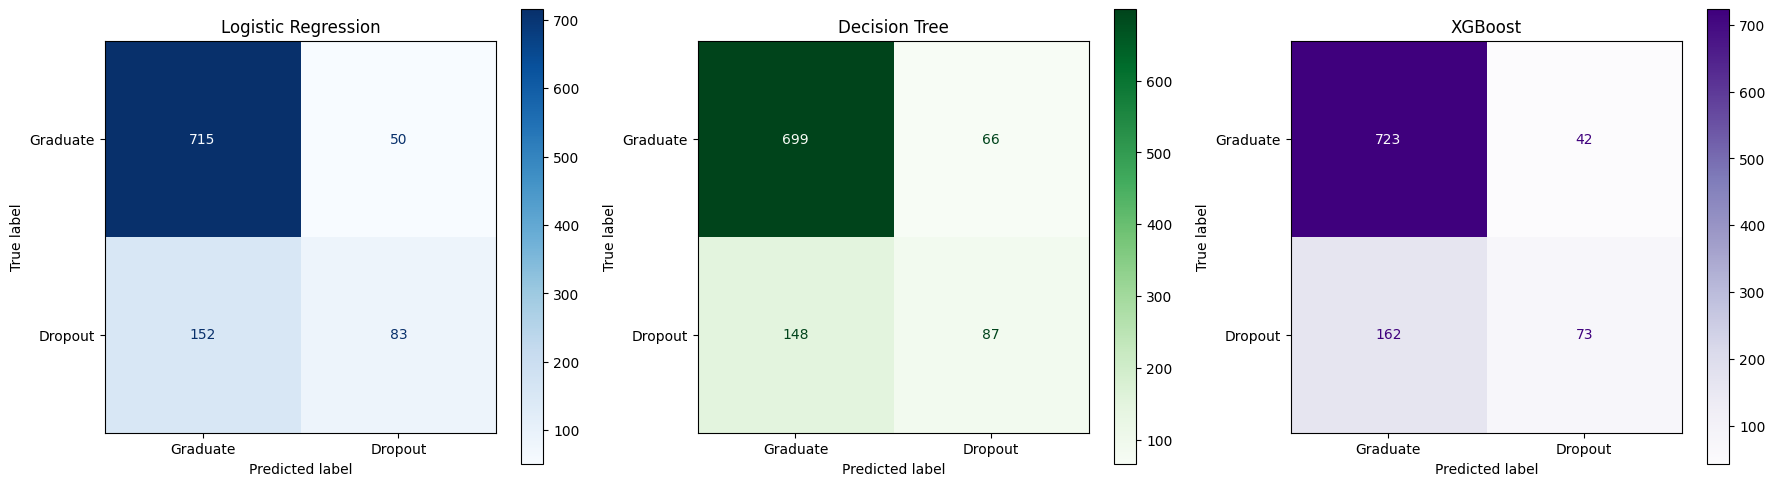

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(18,5))

# Logistic Regression
ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred_lr),
    display_labels=["Graduate", "Dropout"]
).plot(ax=ax[0], cmap="Blues")

ax[0].set_title("Logistic Regression")

# Decision Tree
ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred_dt),
    display_labels=["Graduate", "Dropout"]
).plot(ax=ax[1], cmap="Greens")

ax[1].set_title("Decision Tree")

# XGBoost
ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred_xgb),
    display_labels=["Graduate", "Dropout"]
).plot(ax=ax[2], cmap="Purples")

ax[2].set_title("XGBoost")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

###ROC Curve

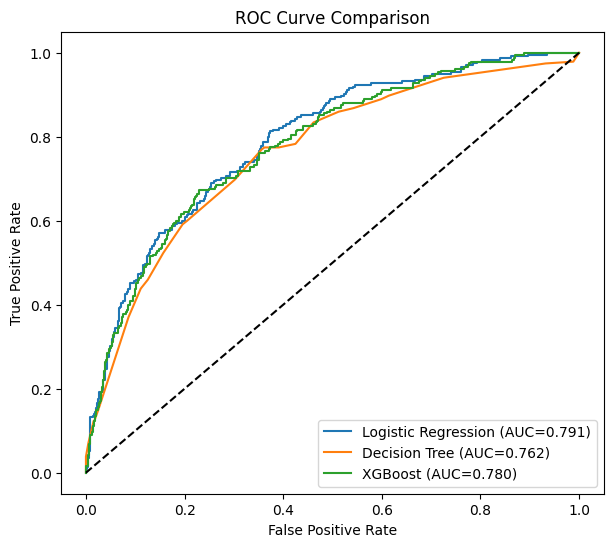

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

prob_lr = best_lr.predict_proba(X_test_scaled)[:,1]
prob_dt = best_dt.predict_proba(X_test)[:,1]
prob_xgb = best_xgb.predict_proba(X_test)[:,1]

fpr_lr,tpr_lr,_ = roc_curve(y_test,prob_lr)
fpr_dt,tpr_dt,_ = roc_curve(y_test,prob_dt)
fpr_xgb,tpr_xgb,_ = roc_curve(y_test,prob_xgb)

auc_lr = roc_auc_score(y_test,prob_lr)
auc_dt = roc_auc_score(y_test,prob_dt)
auc_xgb = roc_auc_score(y_test,prob_xgb)

plt.figure(figsize=(7,6))

plt.plot(fpr_lr,tpr_lr,
         label=f"Logistic Regression (AUC={auc_lr:.3f})")

plt.plot(fpr_dt,tpr_dt,
         label=f"Decision Tree (AUC={auc_dt:.3f})")

plt.plot(fpr_xgb,tpr_xgb,
         label=f"XGBoost (AUC={auc_xgb:.3f})")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig(
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##Feature Importance

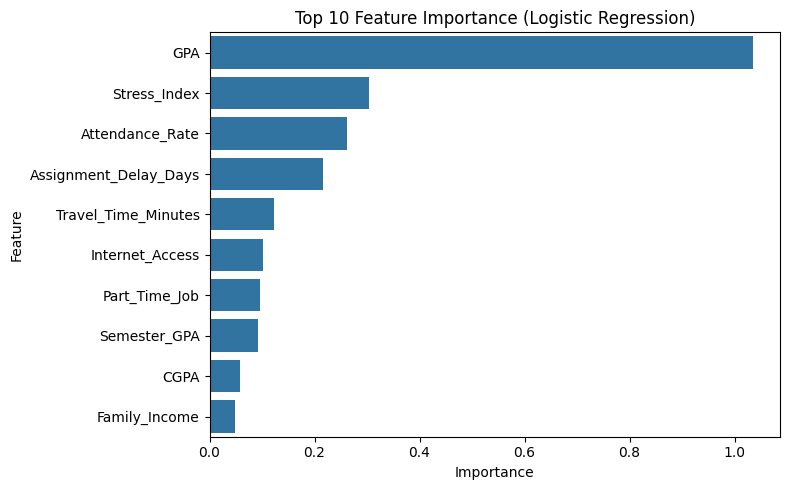

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(best_lr.coef_[0])
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance (Logistic Regression)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

## SHAP Model Interpretation

In [ ]:
!pip install shap -q

In [ ]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

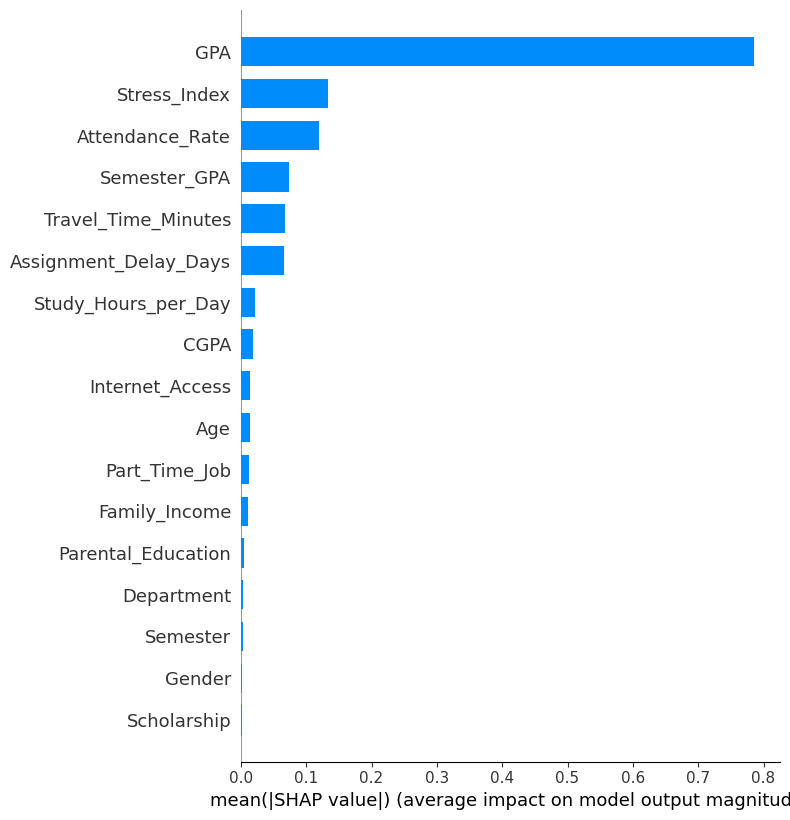

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.savefig(
    "shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

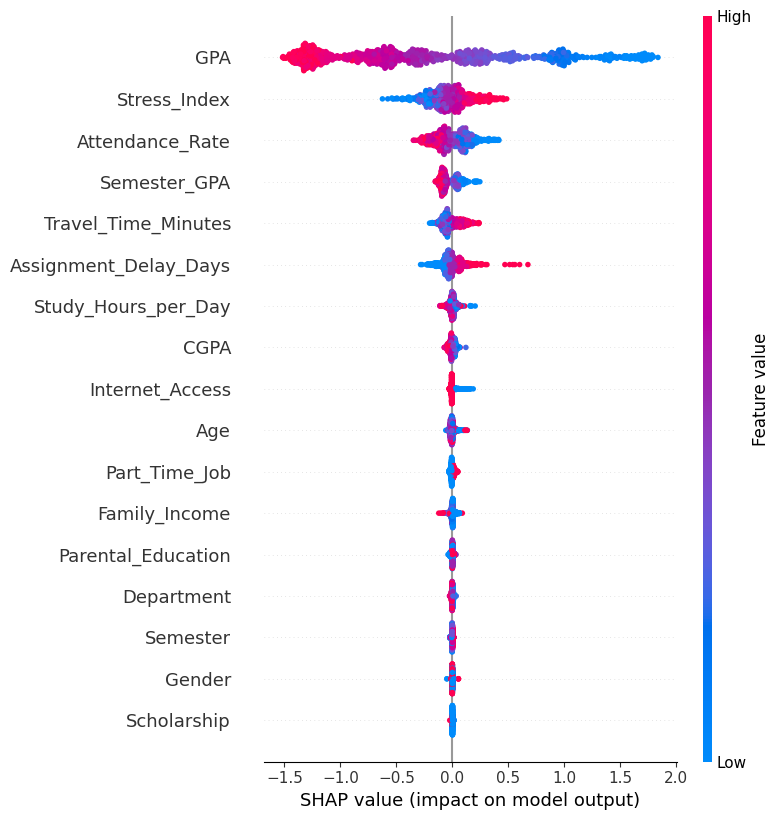

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.savefig(
    "shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##Best Model Selection

Berdasarkan hasil evaluasi terhadap tiga model yang diuji, yaitu Logistic Regression, Decision Tree, dan XGBoost, model terbaik dipilih berdasarkan nilai Accuracy, Precision, Recall, F1-Score, ROC-AUC, serta hasil interpretasi model.

Hasil evaluasi menunjukkan bahwa **Logistic Regression** memberikan performa terbaik dibandingkan model lainnya dengan kemampuan klasifikasi yang lebih baik pada data.

Oleh karena itu, model Logistic Regression dipilih sebagai model akhir yang digunakan pada proses deployment karena memberikan keseimbangan terbaik antara performa prediksi dan interpretabilitas model.

# Deployment Plan


###Save Best Model

In [ ]:
import joblib

joblib.dump(best_lr, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Logistic Regression berhasil disimpan.")

Model Logistic Regression berhasil disimpan.


### Load Best Model

In [ ]:
import joblib

loaded_model = joblib.load("best_model.pkl")

print("Model berhasil dimuat.")
print(loaded_model)

Model berhasil dimuat.
LogisticRegression(C=0.1, max_iter=1000, random_state=42)


### Evaluate Loaded Model

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

pred_loaded = loaded_model.predict(X_test)

acc_loaded = accuracy_score(y_test, pred_loaded)

print("=== EVALUASI LOADED MODEL ===")
print(f"Accuracy : {acc_loaded:.4f}")

print(classification_report(
    y_test,
    pred_loaded,
    target_names=["Graduate", "Dropout"]
))

=== EVALUASI LOADED MODEL ===
Accuracy : 0.7650
              precision    recall  f1-score   support

    Graduate       0.77      1.00      0.87       765
     Dropout       0.00      0.00      0.00       235

    accuracy                           0.77      1000
   macro avg       0.38      0.50      0.43      1000
weighted avg       0.59      0.77      0.66      1000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sample

### Prediction Demo

In [ ]:
import pandas as pd

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)[0]

print("=== HASIL PREDIKSI ===")

if prediction == 0:
    print("Prediksi: Graduate")
else:
    print("Prediksi: Dropout")

=== HASIL PREDIKSI ===
Prediksi: Graduate


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


### Deployment Summary
Model berhasil disimpan dalam format `.pkl` dan dapat digunakan kembali untuk melakukan prediksi tanpa proses pelatihan ulang. Hal ini menunjukkan bahwa model siap untuk diintegrasikan ke dalam aplikasi prediksi kelulusan mahasiswa di masa mendatang.